# Laboratorio: eliminación de anomalías de la imagen

**Integrantes:** completar con los nombres del grupo.

Este notebook estudia ruido impulsivo tipo sal y pimienta. Se aplica el mismo detector contextual y restaurador propio a dos imágenes distintas. La operación principal no usa un filtro de mediana de librería: recorre ventanas, calcula MAD, protege bordes y restaura con vecinos no anómalos.

## 1. Descripción del problema y diseño

La anomalía elegida altera píxeles aislados a valores extremos 0 o 255. Un umbral global no basta porque los extremos también pueden pertenecer al contenido; por eso se compara cada píxel con su contexto local.

El algoritmo usa una ventana impar, mediana local y desviación absoluta mediana (MAD). Marca un píxel solo si es extremo y su desviación supera un umbral robusto. Para restaurarlo, pondera los vecinos no marcados por su cercanía a la mediana local. Los parámetros son iguales en las dos imágenes.

In [1]:
from pathlib import Path
import sys
import numpy as np
from PIL import Image, ImageFilter
from IPython.display import display

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.anomaly_removal import remove_impulses
from src.metrics import detection_metrics, restoration_metrics

## 2. Las dos imágenes de ejemplo

Las escenas son reproducibles y se generan en `scripts/generate_data.py`. La corrupción se inyecta con semillas distintas, pero con la misma densidad y el mismo tipo de anomalía. La imagen limpia se conserva para validar la restauración.

Imagen 1: (128, 128, 3), píxeles alterados=538


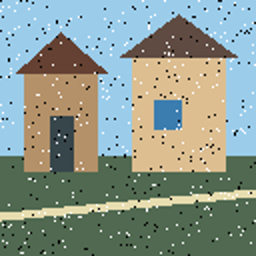

Imagen 2: (128, 128, 3), píxeles alterados=577


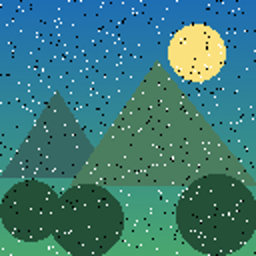

In [2]:
def load_pair(index):
    clean = np.asarray(Image.open(ROOT / f'data/original_{index}/original_{index}.png'))
    corrupted = np.asarray(Image.open(ROOT / f'data/corrupted_{index}/corrupted_{index}.png'))
    truth = np.asarray(Image.open(ROOT / f'data/mask_{index}/mask_{index}.png')) > 0
    return clean, corrupted, truth

for index in (1, 2):
    clean, corrupted, truth = load_pair(index)
    print(f'Imagen {index}: {clean.shape}, píxeles alterados={truth.sum()}')
    display(Image.fromarray(corrupted).resize((256, 256)))

## 3. Ejecución paso a paso del algoritmo

Se fija `window_size=5` para las dos imágenes. La función devuelve el mapa de anomalías y la imagen restaurada; el mapa permite inspeccionar explícitamente la etapa de detección.

Imagen 1: detectados=532


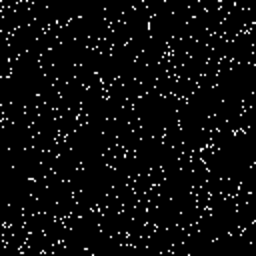

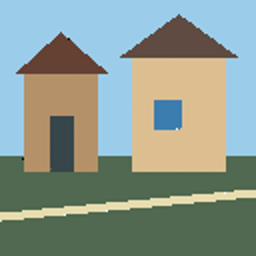

Imagen 2: detectados=573


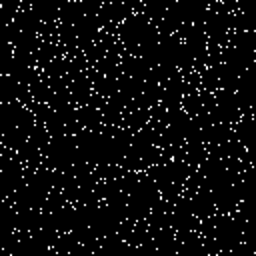

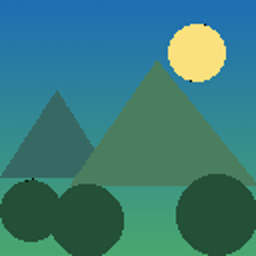

In [3]:
results = {}
for index in (1, 2):
    clean, corrupted, truth = load_pair(index)
    restored, detected = remove_impulses(corrupted, window_size=5)
    results[index] = dict(clean=clean, corrupted=corrupted, truth=truth, detected=detected, restored=restored)
    Image.fromarray(restored).save(ROOT / f'data/output/restored_{index}.png')
    print(f'Imagen {index}: detectados={detected.sum()}')
    display(Image.fromarray(np.where(detected, 255, 0).astype(np.uint8)).resize((256, 256)))
    display(Image.fromarray(restored).resize((256, 256)))

## 4. Validación cuantitativa

Como conocemos las imágenes limpias y la máscara inyectada, se pueden medir tanto la detección como la restauración. También se muestra una mediana de Pillow solo como baseline de referencia; no forma parte de la solución propuesta.

In [4]:
for index, item in results.items():
    det = detection_metrics(item['detected'], item['truth'])
    rest = restoration_metrics(item['clean'], item['restored'])
    baseline = np.asarray(Image.fromarray(item['corrupted']).filter(ImageFilter.MedianFilter(size=5)))
    base_metrics = restoration_metrics(item['clean'], baseline)
    print(f'Imagen {index}')
    print('  detección:', {k: round(v, 4) for k, v in det.items()})
    print('  propuesta:', {k: round(v, 4) for k, v in rest.items()})
    print('  baseline mediana Pillow:', {k: round(v, 4) for k, v in base_metrics.items()})

Imagen 1
  detección: {'precision': 1.0, 'recall': 0.9888, 'f1': 0.9944}
  propuesta: {'mae': 0.0446, 'psnr': 40.8402, 'ssim': 0.9992}
  baseline mediana Pillow: {'mae': 0.535, 'psnr': 30.2763, 'ssim': 0.9911}
Imagen 2
  detección: {'precision': 1.0, 'recall': 0.9931, 'f1': 0.9965}
  propuesta: {'mae': 0.0448, 'psnr': 41.3097, 'ssim': 0.999}
  baseline mediana Pillow: {'mae': 0.3216, 'psnr': 33.8024, 'ssim': 0.9944}


## 5. Conclusiones y referencias

El mismo algoritmo detecta y restaura la anomalía en dos contenidos diferentes sin cambiar sus parámetros. La evaluación usa la máscara conocida para cuantificar generalización y la imagen limpia para cuantificar fidelidad.

La especificación procede de la guía UNIR `colinar03_lab.docx`. La elección de ruido impulsivo y el uso de estadística robusta se fundamentan en los temas de ruido y detección/cancelación de anomalías de la asignatura. La combinación concreta de detector contextual, protección por contraste y restauración ponderada es una implementación propia de este repositorio; no se ha copiado código externo.